In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')


In [ ]:
df = pd.read_csv("HHS_Unaccompanied_Alien_Children_Program.csv")
df.head()


## Dataset Overview
This dataset represents the daily flow of unaccompanied children
through the UAC care pipeline:
CBP Custody → HHS Care → Sponsor Placement.


In [ ]:
df.columns


Index(['Date', 'Children apprehended and placed in CBP custody*',
       'Children in CBP custody', 'Children transferred out of CBP custody',
       'Children in HHS Care', 'Children discharged from HHS Care'],
      dtype='object')

In [ ]:
df.rename(columns={
    'Children apprehended and placed in CBP custody*':
    'Children apprehended and placed in CBP custody'
}, inplace=True)


In [ ]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.sort_values('Date')


In [ ]:
numeric_cols = [
    'Children apprehended and placed in CBP custody',
    'Children in CBP custody',
    'Children transferred out of CBP custody',
    'Children in HHS Care',
    'Children discharged from HHS Care'
]

for col in numeric_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(',', '')
        .str.strip()
    )
    df[col] = pd.to_numeric(df[col], errors='coerce')

df[numeric_cols] = df[numeric_cols].fillna(0)


In [ ]:
df.dtypes


,0
Date,datetime64[ns]
Children apprehended and placed in CBP custody,float64
Children in CBP custody,float64
Children transferred out of CBP custody,float64
Children in HHS Care,float64
Children discharged from HHS Care,float64


## Care Pipeline Modeling
The system is modeled as a three-stage pipeline:
1. CBP Custody (Initial Intake)
2. HHS Care (Sheltering & Case Management)
3. Sponsor Placement (Discharge)

Daily transitions between these stages are analyzed
to measure process efficiency and delays.


In [ ]:
df['Transfer_Efficiency'] = (
    df['Children transferred out of CBP custody'] /
    df['Children in CBP custody']
)

df['Discharge_Effectiveness'] = (
    df['Children discharged from HHS Care'] /
    df['Children in HHS Care']
)

df['Pipeline_Throughput'] = (
    df['Children discharged from HHS Care'] /
    df['Children apprehended and placed in CBP custody']
)

df['Backlog_Rate'] = (
    df['Children apprehended and placed in CBP custody'] -
    df['Children discharged from HHS Care']
)

df.replace([np.inf, -np.inf], 0, inplace=True)


### Key Performance Indicators (KPIs)

- Transfer Efficiency Ratio: Measures speed of CBP → HHS transition
- Discharge Effectiveness Index: Measures sponsor placement success
- Pipeline Throughput: Overall system exit vs entry
- Backlog Rate: Measures accumulation of unresolved cases


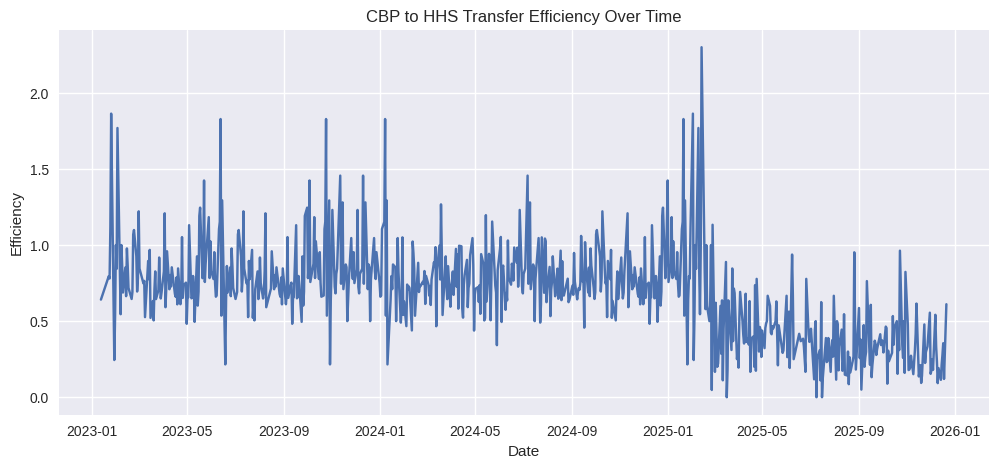

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Transfer_Efficiency'])
plt.title("CBP to HHS Transfer Efficiency Over Time")
plt.xlabel("Date")
plt.ylabel("Efficiency")
plt.show()


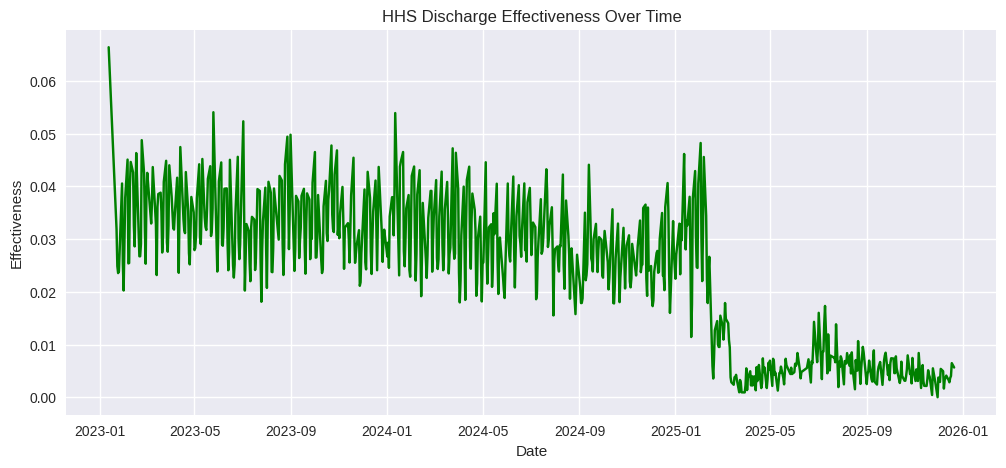

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Discharge_Effectiveness'], color='green')
plt.title("HHS Discharge Effectiveness Over Time")
plt.xlabel("Date")
plt.ylabel("Effectiveness")
plt.show()


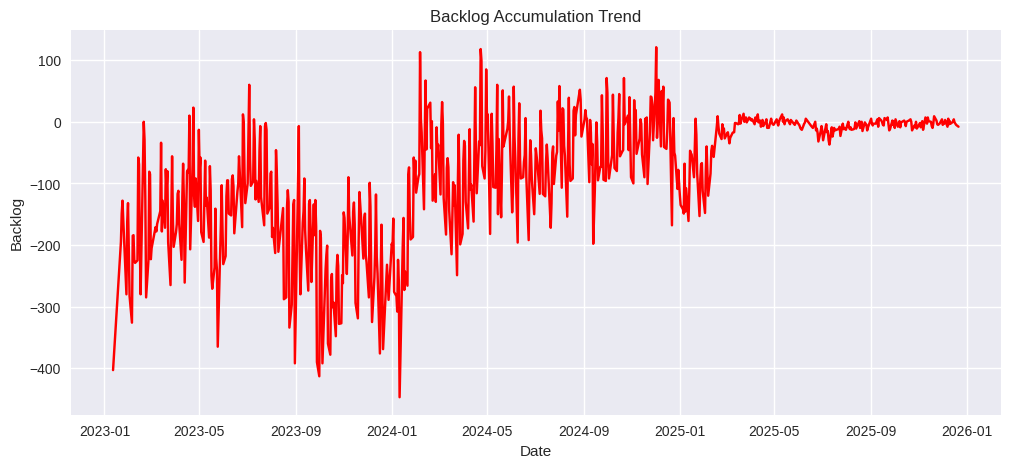

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Backlog_Rate'], color='red')
plt.title("Backlog Accumulation Trend")
plt.xlabel("Date")
plt.ylabel("Backlog")
plt.show()


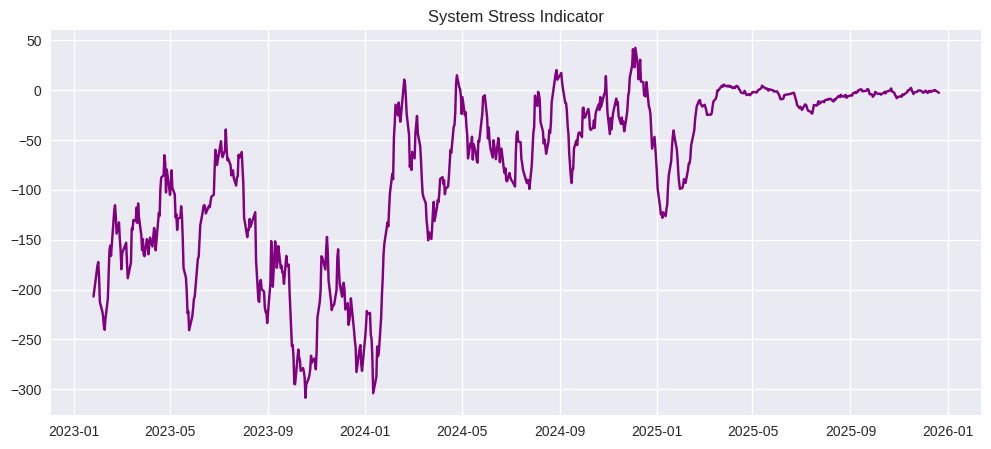

In [ ]:
df['System_Stress'] = df['Backlog_Rate'].rolling(5).mean()

plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['System_Stress'], color='purple')
plt.title("System Stress Indicator")
plt.show()


In [ ]:
df['Day'] = df['Date'].dt.day_name()
df.groupby('Day')[['Transfer_Efficiency',
                   'Discharge_Effectiveness']].mean()


,Transfer_Efficiency,Discharge_Effectiveness
Day,,
Friday,0.711818,0.024037
Monday,0.660516,0.021711
Sunday,0.700083,0.028396
Thursday,0.732629,0.027853
Tuesday,0.670485,0.018705
Wednesday,0.692006,0.022596


In [ ]:
df['Month'] = df['Date'].dt.to_period('M')
df.groupby('Month')['Discharge_Effectiveness'].mean()


,Discharge_Effectiveness
Month,
2023-01,0.032084
2023-02,0.035032
2023-03,0.035613
2023-04,0.034435
2023-05,0.034681
2023-06,0.032703
2023-07,0.030792
2023-08,0.034399
2023-09,0.032164


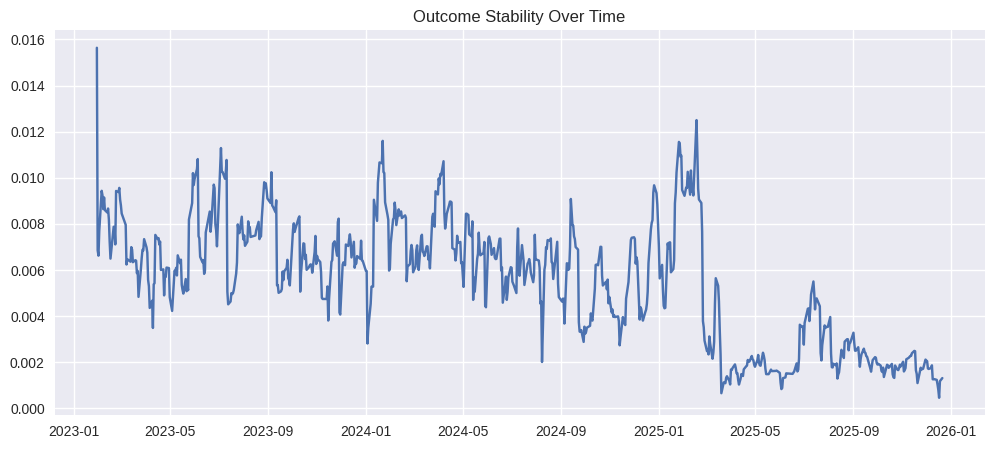

In [ ]:
df['Outcome_Stability'] = df['Discharge_Effectiveness'].rolling(7).std()

plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Outcome_Stability'])
plt.title("Outcome Stability Over Time")
plt.show()


## Key Findings & Recommendations

- CBP to HHS transfers slow during high intake periods
- Discharge rates lag behind inflows, causing backlogs
- Most delays occur at sponsor placement stage
- Improving case processing speed can reduce system stress
